In [33]:
# ============================================================
# Minimal notebook: for ONE (B, n_i, phi, EXP_FOLDER),
# pick BEST tau per seed by ELBO, then summarize across seeds:
#
# Rows:
#   Beta
#   Phi
#   Tausq
#   Sigmasq
#   n_correct_perm_x
#   n_correct_perm_s
#   ELBO          (NaN for GPmodel / GPArealModel)
#
# Columns:
#   GPmodel
#   GPArealModel
#   VI_best_tau_by_ELBO
#
# Notes:
# - Uses results from ../data/results/{EXP_FOLDER}/B_{B}_n_{n_i}/phi_{phi}/results_seed_{seed}.pt
# - Uses truth perms from ../data/vary_B2/B_{B}_n_{n_i}/phi_{phi}/data_seed_{seed}.pt
# - Best tau chosen per seed using ELBO score = mean(last K ELBOs) (K=5 by default).
# - Fixes "ELBO becomes 0" issue by trimming trailing zeros in loss_vector (early stop padding).
# - PyTorch 2.6+: torch.load(..., weights_only=False)
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
import torch
from collections import defaultdict

# ---- user choices ----
EXP_FOLDER = "vary_B2"   # "vary_B2" or "vary_B2_annealed"
B = 49
n_i =10
phi = 2.0
TAIL_K = 10                    # smoothing for ELBO score (mean of last K)

TRIM_TRAILING_ZEROS = True      # important if early stopping pads loss_vector with zeros
ZERO_ATOL = 0.0                 # set 1e-12 if you want tolerant trimming

RESULTS_DIR = os.path.join("..", "data", "results", EXP_FOLDER, f"B_{B}_n_{n_i}", f"phi_{phi}")
DATA_DIR    = os.path.join("..", "data", "vary_B2",            f"B_{B}_n_{n_i}", f"phi_{phi}")

# ---- round_to_perm from your project ----
import sys
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from utils import round_to_perm

def load_pt(path):
    return torch.load(path, map_location="cpu", weights_only=False)

def summarize(vals):
    return {"mean": np.nanmean(vals), "sd": np.nanstd(vals)}

def to_float(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        return float(x.reshape(-1)[0].item()) if x.numel() else np.nan
    try:
        return float(np.asarray(x).reshape(-1)[0])
    except Exception:
        return np.nan

def trim_trailing_zeros(x, atol=0.0):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return x
    i = x.size - 1
    while i > 0 and np.isfinite(x[i]) and np.isclose(x[i], 0.0, atol=atol):
        i -= 1
    return x[:i+1]

def elbo_score_from_trace(trace, tail_k=5):
    if trace is None:
        return None, None
    if isinstance(trace, torch.Tensor):
        trace = trace.detach().cpu().numpy()
    x = np.asarray(trace, dtype=float).reshape(-1)
    if x.size == 0:
        return None, None
    if TRIM_TRAILING_ZEROS:
        x = trim_trailing_zeros(x, atol=ZERO_ATOL)
    if x.size == 0 or np.max(np.abs(x)) == 0.0:
        return None, x
    k = min(int(tail_k), x.size)
    return float(np.nanmean(x[-k:])), x

def get_vi_tau_keys(result_dict):
    out = []
    for k in result_dict.keys():
        if isinstance(k, str) and k.startswith("VIGP_unlinked_tau_"):
            try:
                tau = float(k.split("VIGP_unlinked_tau_")[1])
                out.append((tau, k))
            except Exception:
                pass
    return sorted(out, key=lambda z: z[0])

# ---- find all result files available ----
result_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "results_seed_*.pt")))
if len(result_files) == 0:
    raise FileNotFoundError(f"No results at: {RESULTS_DIR}/results_seed_*.pt")

seed_re = re.compile(r"results_seed_(\d+)\.pt$")

# ---- collect GP / Areal across seeds (as usual) ----
stats = {
    "GPmodel": defaultdict(list),
    "GPArealModel": defaultdict(list),
    "VI_best": defaultdict(list)  # stores chosen-per-seed VI values (after best tau selection)
}

missing_data = 0
missing_any_vi = 0
missing_valid_vi = 0

for path in result_files:
    m = seed_re.search(os.path.basename(path))
    if m is None:
        continue
    seed = int(m.group(1))

    # need data file for true perms (skip seed if missing)
    dp = os.path.join(DATA_DIR, f"data_seed_{seed}.pt")
    if not os.path.exists(dp):
        missing_data += 1
        continue
    data = load_pt(dp)
    perm_matrix_x = data["perm_matrix_x"]
    perm_matrix_s = data["perm_matrix_s"]

    # load results
    result = load_pt(path)

    # ---- GP + Areal (no ELBO row; we'll fill NaN later) ----
    for model in ["GPmodel", "GPArealModel"]:
        if model not in result:
            continue
        mm = result[model]

        beta = mm.get("beta", np.nan)
        if isinstance(beta, torch.Tensor):
            beta = beta.detach().cpu().numpy()
        beta = float(np.asarray(beta).reshape(-1)[0]) if beta is not None else np.nan

        stats[model]["Beta"].append(beta)
        stats[model]["Phi"].append(to_float(mm.get("phi", np.nan)))
        stats[model]["Tausq"].append(to_float(mm.get("tausq", np.nan)))
        stats[model]["Sigmasq"].append(to_float(mm.get("sigmasq", np.nan)))
        stats[model]["n_correct_perm_x"].append(np.nan)
        stats[model]["n_correct_perm_s"].append(np.nan)
        stats[model]["ELBO"].append(np.nan)

    # ---- VI: choose best tau per seed by ELBO ----
    vi_keys = get_vi_tau_keys(result)
    if len(vi_keys) == 0:
        missing_any_vi += 1
        continue

    best_tau = None
    best_score = -np.inf
    best_key = None
    best_trace_used = None

    for tau, key in vi_keys:
        vi = result.get(key, None)
        if not isinstance(vi, dict):
            continue
        score, trace_used = elbo_score_from_trace(vi.get("loss_vector", None), tail_k=TAIL_K)
        if score is None or not np.isfinite(score):
            continue
        if score > best_score:
            best_score = score
            best_tau = tau
            best_key = key
            best_trace_used = trace_used

    if best_key is None:
        missing_valid_vi += 1
        continue

    vi = result[best_key]

    # parameters (same extraction logic as your example)
    beta = to_float(vi.get("mu_lambda_beta", np.nan))
    mean_phi = to_float(vi.get("mean_phi", np.nan))

    a1 = to_float(vi.get("lambda_a1", np.nan)); b1 = to_float(vi.get("lambda_b1", np.nan))
    a2 = to_float(vi.get("lambda_a2", np.nan)); b2 = to_float(vi.get("lambda_b2", np.nan))

    sigmasq = (b1 / (a1 - 1.0)) if np.isfinite(a1) and a1 > 1 else np.nan
    tausq   = (b2 / (a2 - 1.0)) if np.isfinite(a2) and a2 > 1 else np.nan

    MX = vi.get("M_X_star", None)
    MS = vi.get("M_S_star", None)

    n_correct_x = np.nan
    n_correct_s = np.nan
    if isinstance(MX, torch.Tensor):
        MXn = MX.detach().cpu().numpy()
        n_correct_x = torch.sum(perm_matrix_x.T * round_to_perm(MXn)).item()
    if isinstance(MS, torch.Tensor):
        MSn = MS.detach().cpu().numpy()
        n_correct_s = torch.sum(perm_matrix_s.T * round_to_perm(MSn)).item()

    stats["VI_best"]["Beta"].append(beta)
    stats["VI_best"]["Phi"].append(mean_phi)
    stats["VI_best"]["Tausq"].append(tausq)
    stats["VI_best"]["Sigmasq"].append(sigmasq)
    stats["VI_best"]["n_correct_perm_x"].append(n_correct_x)
    stats["VI_best"]["n_correct_perm_s"].append(n_correct_s)
    stats["VI_best"]["ELBO"].append(best_score)

# ---- summarize to mean (sd) strings ----
def fmt_mean_sd(arr):
    s = summarize(arr)
    return f"{s['mean']:.4f} ({s['sd']:.4f})"

rows = ["Beta","Phi","Tausq","Sigmasq","n_correct_perm_x","n_correct_perm_s","ELBO"]
cols = ["GPmodel","GPArealModel","VI_best_tau_by_ELBO"]

table = pd.DataFrame(index=rows, columns=cols, dtype=object)

for model, colname in [("GPmodel","GPmodel"), ("GPArealModel","GPArealModel"), ("VI_best","VI_best_tau_by_ELBO")]:
    for r in rows:
        vals = stats[model].get(r, [])
        if len(vals) == 0:
            table.loc[r, colname] = "nan (nan)"
        else:
            table.loc[r, colname] = fmt_mean_sd(vals)

print(f"EXP_FOLDER={EXP_FOLDER} | B={B}, n_i={n_i}, phi={phi}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Data dir   : {DATA_DIR}")
print(f"Seeds used (VI_best): {len(stats['VI_best'].get('ELBO', []))}")
print(f"Missing data seeds: {missing_data} | Seeds with no VI: {missing_any_vi} | Seeds with no valid VI ELBO: {missing_valid_vi}")
print(table)

FileNotFoundError: No results at: ../data/results/vary_B2/B_49_n_10/phi_2.0/results_seed_*.pt

seeds with best tau = 0.2: [10, 100, 11, 12, 13, 14, 15, 16, 17, 18]


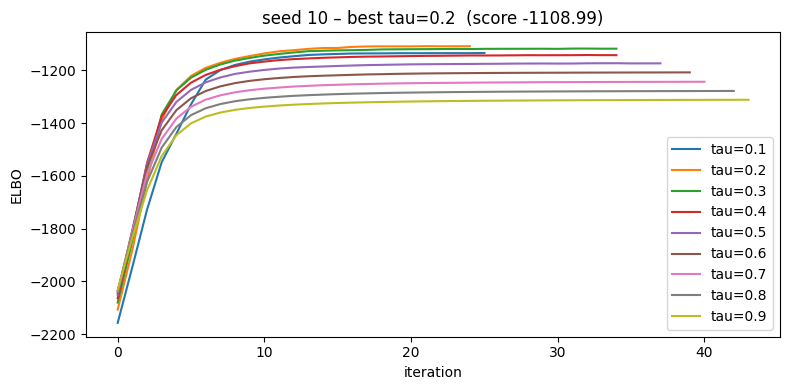

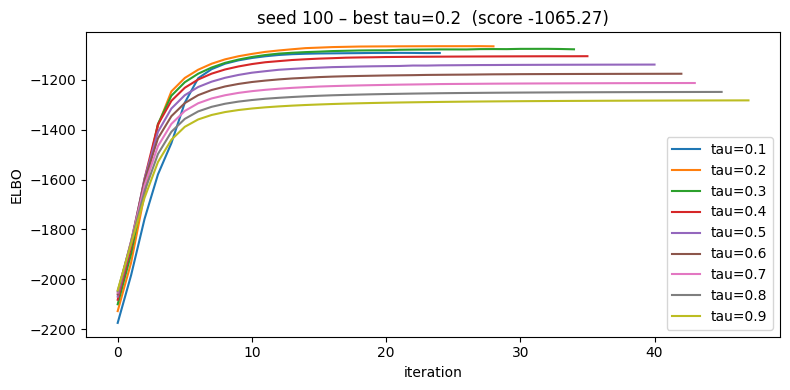

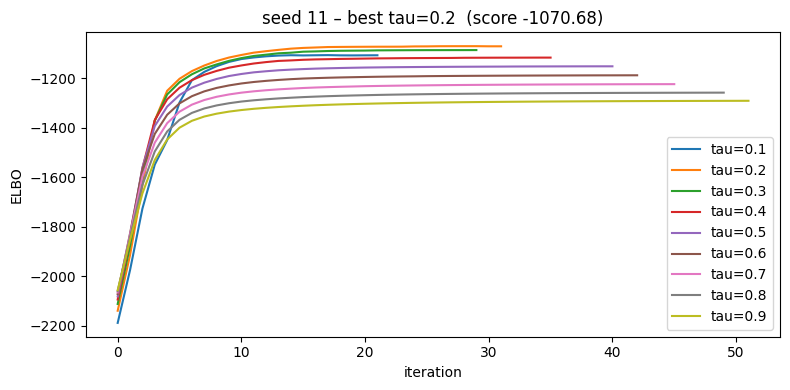

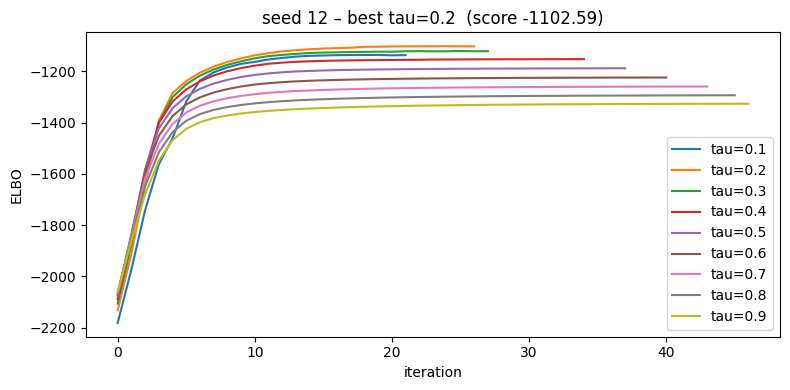

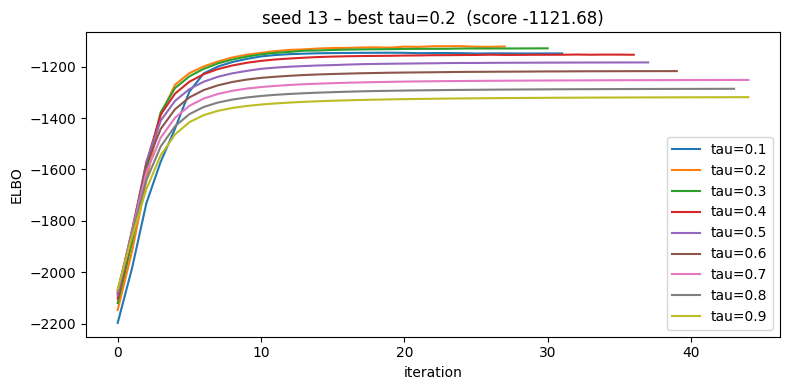

other seeds (first 5): []


In [21]:
import matplotlib.pyplot as plt

def plot_elbo_for_seed(seed):
    path = os.path.join(RESULTS_DIR, f"results_seed_{seed}.pt")
    if not os.path.exists(path):
        print("no results file for seed", seed)
        return
    res = load_pt(path)
    vi_keys = get_vi_tau_keys(res)
    if not vi_keys:
        print("seed", seed, "has no VI entries")
        return

    best_tau, best_score = None, -np.inf
    plt.figure(figsize=(8, 4))
    for tau, key in vi_keys:
        vi = res.get(key, {})
        score, trace = elbo_score_from_trace(vi.get("loss_vector", None),
                                             tail_k=TAIL_K)
        if trace is None or len(trace) == 0:
            continue
        plt.plot(trace, label=f"tau={tau}")
        if score is not None and np.isfinite(score) and score > best_score:
            best_score = score
            best_tau = tau

    plt.title(f"seed {seed} – best tau={best_tau}  (score {best_score:.2f})")
    plt.xlabel("iteration")
    plt.ylabel("ELBO")
    plt.legend()
    plt.tight_layout()
    plt.show()


# seeds for which the best‑tau selection gave 0.2
seeds02 = [s for s, (tau, _) in best_by_seed.items() if tau == 0.2]
print("seeds with best tau = 0.2:", seeds02[:10])
for s in seeds02[:5]:
    plot_elbo_for_seed(s)

# and a few examples with a different chosen tau, for comparison
other = [s for s, (tau, _) in best_by_seed.items() if tau != 0.2]
print("other seeds (first 5):", other[:5])
for s in other[:3]:
    plot_elbo_for_seed(s)
